In [9]:
#Primero importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#Cargamos el archivo xlsx con los datos de ventas
ventas = pd.read_excel('Datos_CLV_2026_Tec_v2.xlsx', sheet_name='Ventas_CLV_2022_2026')
ventas

,fecha_documento,folio_abreviado,folio,articulo_id,clave_articulo,nombre_articulo,marca,precio_unitario,total_unidades,total_neto,nombre_cliente,estado,ciudad,cp,vendedor
0,11.09.2026,B00,B00013017,7688,MFTL374M2,MFT L37 4M2,VITA,172.413793,1,172.41,HUGO CARRILLO SANPEDRO SF,Ciudad de México,CDMX,6100.0,JAVIERCAD
1,11.09.2026,B00,B00013017,7895,MFTPL313R2.5,MFT PL31 3R2.5,VITA,172.413793,1,172.41,HUGO CARRILLO SANPEDRO SF,Ciudad de México,CDMX,6100.0,JAVIERCAD
2,11.09.2026,B00,B00013017,7985,MFTPU313R2.5,MFT PU31 3R2.5,VITA,172.413793,2,344.83,HUGO CARRILLO SANPEDRO SF,Ciudad de México,CDMX,6100.0,JAVIERCAD
3,11.09.2026,B00,B00013017,8258,MFTT464M2,MFT T46 4M2,VITA,172.413793,2,344.83,HUGO CARRILLO SANPEDRO SF,Ciudad de México,CDMX,6100.0,JAVIERCAD
4,11.09.2026,A00,A00018080,7613,MFTL332M2,MFT L33 2M2,VITA,156.740000,1,156.74,JUAN PEDRO OLVERA ALONSO,Querétaro,Querétaro,76079.0,SERGIO SANCHEZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114496,02.01.2023,A00,A00006638,11864,VM13OP212G,VM13 OPAQUE OP2 12G,VITA,498.830000,1,498.83,SILVIA ESTHELA GONZALEZ MAR,Tamaulipas,Tampico,89000.0,ENRIQUE
114497,02.01.2023,B00,B00005123,5801,APG12.510PA1,CAMEO PRESS INGOT BOX HT A1,AIDITE,1120.689655,1,1120.69,DENTALUS,Estado de México,Naucalpan de Juárez,53140.0,DIEGO
114498,02.01.2023,B00,B00005123,5804,CPIBHTA2,CAMEO PRESS INGOT BOX HT A2,AIDITE,1120.689655,1,1120.69,DENTALUS,Estado de México,Naucalpan de Juárez,53140.0,DIEGO
114499,02.01.2023,A00,A00006639,4235,760661,FRESA ROTO RFID 1.0 ZI DM,AG,1215.517000,1,1215.52,OLIVIA GARCIA PINEDA,Puebla,Puebla,72430.0,ALEJANDRA


In [11]:
#Verificamos si hay valores nulos en el DataFrame
ventas.isnull().sum()

fecha_documento       0
folio_abreviado       0
folio                 0
articulo_id           0
clave_articulo        0
nombre_articulo       0
marca                 0
precio_unitario       0
total_unidades        0
total_neto            0
nombre_cliente        0
estado                0
ciudad                0
cp                 5188
vendedor              0
dtype: int64

In [12]:
#Separamos las variables cuantitativas que representan medidas de venta
#No incluimos identificadores ni el código postal porque no son magnitudes de venta
variables_cuantitativas = ['precio_unitario', 'total_unidades', 'total_neto']

#Creamos una copia para conservar los datos originales
ventas_procesadas = ventas.copy()

#Convertimos la fecha a un tipo fecha para trabajar correctamente con ella
ventas_procesadas['fecha_documento'] = pd.to_datetime(
    ventas_procesadas['fecha_documento'],
    format='%d.%m.%Y'
)

#Calculamos los límites del método del rango intercuartílico (IQR)
q1 = ventas_procesadas[variables_cuantitativas].quantile(0.25)
q3 = ventas_procesadas[variables_cuantitativas].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

#Contamos cuántos valores atípicos hay en cada variable cuantitativa
outliers_por_variable = ((ventas_procesadas[variables_cuantitativas] < limite_inferior) |
                         (ventas_procesadas[variables_cuantitativas] > limite_superior)).sum()
outliers_por_variable

precio_unitario     9418
total_unidades     16371
total_neto         11515
dtype: int64

## Preprocesamiento: valores nulos y valores atípicos

Se conserva una copia del archivo original y se procesa el DataFrame paso a paso.

In [13]:
#Identificamos los valores nulos por columna
nulos_antes = ventas_procesadas.isnull().sum()
nulos_antes

fecha_documento       0
folio_abreviado       0
folio                 0
articulo_id           0
clave_articulo        0
nombre_articulo       0
marca                 0
precio_unitario       0
total_unidades        0
total_neto            0
nombre_cliente        0
estado                0
ciudad                0
cp                 5188
vendedor              0
dtype: int64

In [14]:
#Sustituimos los valores nulos del código postal con la moda
#La moda es adecuada porque el código postal funciona como un dato categórico
moda_cp = ventas_procesadas['cp'].mode()[0]
ventas_procesadas['cp'] = ventas_procesadas['cp'].fillna(moda_cp)

#Comprobamos que ya no existan valores nulos
nulos_despues = ventas_procesadas.isnull().sum()
nulos_despues

fecha_documento    0
folio_abreviado    0
folio              0
articulo_id        0
clave_articulo     0
nombre_articulo    0
marca              0
precio_unitario    0
total_unidades     0
total_neto         0
nombre_cliente     0
estado             0
ciudad             0
cp                 0
vendedor           0
dtype: int64

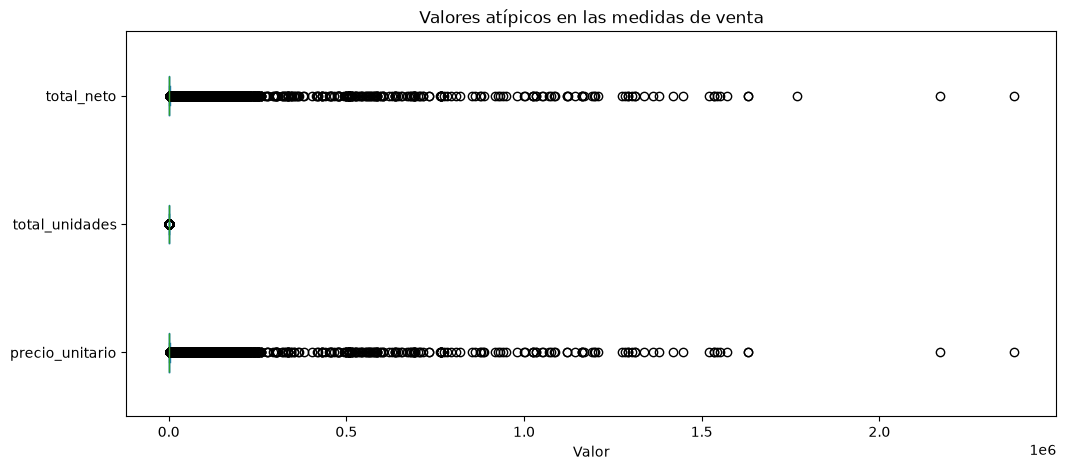

In [15]:
#Visualizamos los valores atípicos antes de corregirlos
ventas_procesadas[variables_cuantitativas].plot(kind='box', vert=False, figsize=(12, 5))
plt.title('Valores atípicos en las medidas de venta')
plt.xlabel('Valor')
plt.show()

In [16]:
#Reemplazamos los valores atípicos por la mediana de cada variable
for variable in variables_cuantitativas:
    mascara_outlier = ((ventas_procesadas[variable] < limite_inferior[variable]) |
                       (ventas_procesadas[variable] > limite_superior[variable]))
    mediana_variable = ventas_procesadas[variable].median()
    ventas_procesadas.loc[mascara_outlier, variable] = mediana_variable

#Contamos nuevamente los valores fuera de los límites originales
outliers_despues = ((ventas_procesadas[variables_cuantitativas] < limite_inferior) |
                    (ventas_procesadas[variables_cuantitativas] > limite_superior)).sum()
outliers_despues

precio_unitario    0
total_unidades     0
total_neto         0
dtype: int64

## Análisis univariado de variables categóricas

Para cada variable se obtiene una tabla de frecuencias y una gráfica de barras. En las variables con muchos valores distintos se muestran los 10 valores más frecuentes para facilitar la lectura.

In [18]:
#Análisis univariado de nombre_articulo
frecuencia_articulo = ventas_procesadas['nombre_articulo'].value_counts().head(10).reset_index()
frecuencia_articulo.columns = ['nombre_articulo', 'frecuencia']
frecuencia_articulo['porcentaje'] = frecuencia_articulo['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_articulo

,nombre_articulo,frecuencia,porcentaje
0,FRESA ROTO RFID 1.0 ZI DM,1703,1.487323
1,FRESA ROTO RFID 2.5 ZI DM,1576,1.376407
2,MFT PU31 2M2,1415,1.235797
3,MFT PU33 2M2,1256,1.096934
4,CAMEO PRESS INGOT BOX LT A2,1181,1.031432
5,CAMEO PRESS INGOT BOX HT A1,1177,1.027939
6,MFT PL31 2M2,1124,0.981651
7,CAMEO PRESS INGOT BOX HT A2,1089,0.951083
8,FRESA ROTO RFID 0.6 ZI DM,1031,0.900429
9,MFT PL33 2M2,988,0.862875


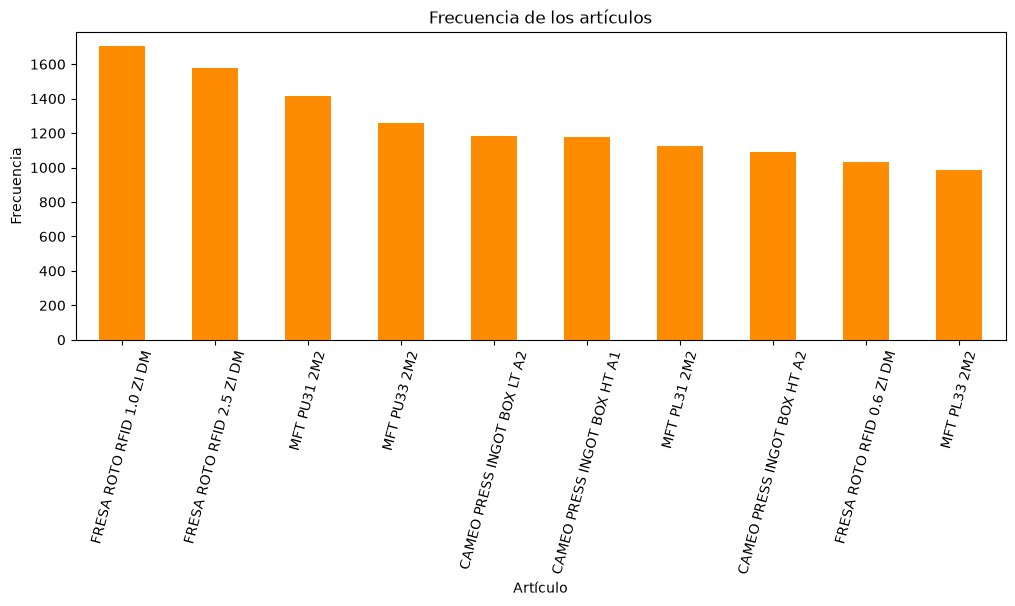

In [24]:
#Gráfica de los artículos con mayor frecuencia
frecuencia_articulo.set_index('nombre_articulo')['frecuencia'].plot(kind='bar', figsize=(12, 4), color='darkorange')
plt.title('Frecuencia de los artículos')
plt.xlabel('Artículo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=75)
plt.show()

In [17]:
#Análisis univariado de fecha_documento
frecuencia_fecha = ventas_procesadas['fecha_documento'].value_counts().head(10).reset_index()
frecuencia_fecha.columns = ['fecha_documento', 'frecuencia']
frecuencia_fecha['porcentaje'] = frecuencia_fecha['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_fecha

,fecha_documento,frecuencia,porcentaje
0,2025-12-15,1497,1.307412
1,2024-03-12,454,0.396503
2,2023-11-30,426,0.372049
3,2023-06-30,405,0.353709
4,2025-10-31,387,0.337988
5,2025-10-15,350,0.305674
6,2026-01-30,348,0.303927
7,2023-05-30,342,0.298687
8,2025-02-17,335,0.292574
9,2025-01-31,331,0.289080


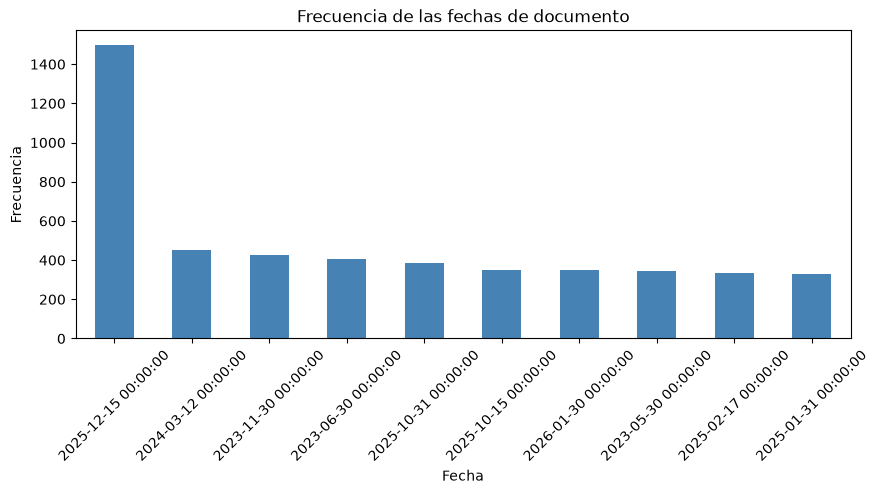

In [23]:
#Gráfica de las fechas con mayor frecuencia
frecuencia_fecha.set_index('fecha_documento')['frecuencia'].plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Frecuencia de las fechas de documento')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [19]:
#Análisis univariado de marca
frecuencia_marca = ventas_procesadas['marca'].value_counts().reset_index()
frecuencia_marca.columns = ['marca', 'frecuencia']
frecuencia_marca['porcentaje'] = frecuencia_marca['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_marca

,marca,frecuencia,porcentaje
0,VITA,59107,51.621383
1,AG,21295,18.598091
2,AIDITE,14819,12.942245
3,JENSE,4044,3.531847
4,HUGE,3782,3.303028
5,PHROZ,2908,2.539716
6,Schef,1184,1.034052
7,MEDIT,1091,0.952830
8,YETI,1003,0.875975
9,Komet,970,0.847154


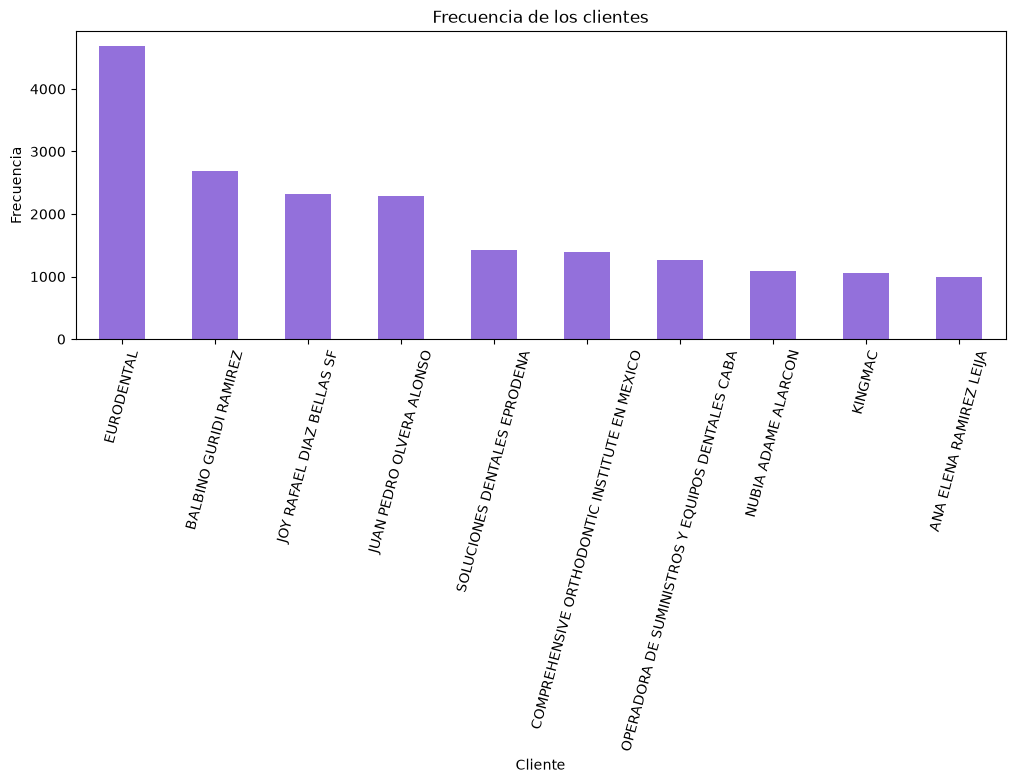

In [26]:
#Gráfica de los clientes con mayor frecuencia
frecuencia_cliente.set_index('nombre_cliente')['frecuencia'].plot(kind='bar', figsize=(12, 4), color='mediumpurple')
plt.title('Frecuencia de los clientes')
plt.xlabel('Cliente')
plt.ylabel('Frecuencia')
plt.xticks(rotation=75)
plt.show()

In [20]:
#Análisis univariado de nombre_cliente
frecuencia_cliente = ventas_procesadas['nombre_cliente'].value_counts().head(10).reset_index()
frecuencia_cliente.columns = ['nombre_cliente', 'frecuencia']
frecuencia_cliente['porcentaje'] = frecuencia_cliente['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_cliente

,nombre_cliente,frecuencia,porcentaje
0,EURODENTAL,4690,4.096034
1,BALBINO GURIDI RAMIREZ,2685,2.344958
2,JOY RAFAEL DIAZ BELLAS SF,2323,2.028803
3,JUAN PEDRO OLVERA ALONSO,2296,2.005223
4,SOLUCIONES DENTALES EPRODENA,1423,1.242784
5,COMPREHENSIVE ORTHODONTIC INSTITUTE EN MEXICO,1400,1.222697
6,OPERADORA DE SUMINISTROS Y EQUIPOS DENTALES CABA,1264,1.103920
7,NUBIA ADAME ALARCON,1089,0.951083
8,KINGMAC,1050,0.917023
9,ANA ELENA RAMIREZ LEIJA,993,0.867241


In [22]:
#Análisis univariado de vendedor
frecuencia_vendedor = ventas_procesadas['vendedor'].value_counts().reset_index()
frecuencia_vendedor.columns = ['vendedor', 'frecuencia']
frecuencia_vendedor['porcentaje'] = frecuencia_vendedor['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_vendedor

,vendedor,frecuencia,porcentaje
0,DIEGO,12480,10.899468
1,LUIS,11926,10.415630
2,ALEJANDRA,7374,6.440118
3,ESMERALDA,7178,6.268941
4,RENE,6729,5.876805
...,...,...,...
134,TIENDA EN LINEA,2,0.001747
135,FERNANDA BO,1,0.000873
136,JESSICALI,1,0.000873
137,BO PILARFLO,1,0.000873


In [29]:
#Guardamos el DataFrame procesado para utilizarlo en el análisis posterior
ventas_procesadas.to_excel('Ventas_CLV_2022_2026_procesadas.xlsx', index=False)
ventas_procesadas.info()

<class 'pandas.DataFrame'>
RangeIndex: 114501 entries, 0 to 114500
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   fecha_documento  114501 non-null  datetime64[us]
 1   folio_abreviado  114501 non-null  str           
 2   folio            114501 non-null  str           
 3   articulo_id      114501 non-null  int64         
 4   clave_articulo   114501 non-null  object        
 5   nombre_articulo  114501 non-null  str           
 6   marca            114501 non-null  str           
 7   precio_unitario  114501 non-null  float64       
 8   total_unidades   114501 non-null  int64         
 9   total_neto       114501 non-null  float64       
 10  nombre_cliente   114501 non-null  str           
 11  estado           114501 non-null  str           
 12  ciudad           114501 non-null  str           
 13  cp               114501 non-null  float64       
 14  vendedor         114501 non-nul

In [28]:
#Resumen de las categorías más frecuentes por variable
resumen_frecuencias = pd.DataFrame({
    'variable': ['fecha_documento', 'nombre_articulo', 'marca', 'nombre_cliente', 'estado', 'vendedor'],
    'categoria_mas_frecuente': [
        ventas_procesadas['fecha_documento'].mode()[0],
        ventas_procesadas['nombre_articulo'].mode()[0],
        ventas_procesadas['marca'].mode()[0],
        ventas_procesadas['nombre_cliente'].mode()[0],
        ventas_procesadas['estado'].mode()[0],
        ventas_procesadas['vendedor'].mode()[0]
    ],
    'frecuencia': [
        ventas_procesadas['fecha_documento'].value_counts().max(),
        ventas_procesadas['nombre_articulo'].value_counts().max(),
        ventas_procesadas['marca'].value_counts().max(),
        ventas_procesadas['nombre_cliente'].value_counts().max(),
        ventas_procesadas['estado'].value_counts().max(),
        ventas_procesadas['vendedor'].value_counts().max()
    ]
})
resumen_frecuencias

,variable,categoria_mas_frecuente,frecuencia
0,fecha_documento,2025-12-15 00:00:00,1497
1,nombre_articulo,FRESA ROTO RFID 1.0 ZI DM,1703
2,marca,VITA,59107
3,nombre_cliente,EURODENTAL,4690
4,estado,Ciudad de México,24337
5,vendedor,DIEGO,12480


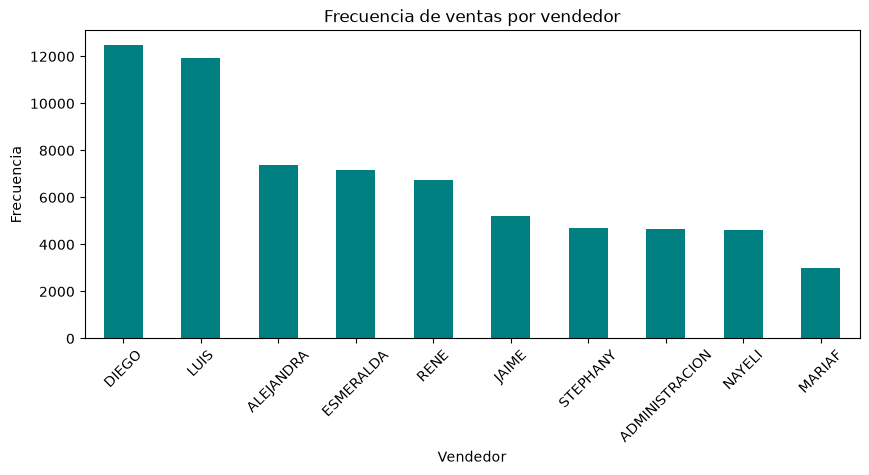

In [31]:
#Gráfica de los 10 vendedores con mayor frecuencia
frecuencia_vendedor.head(10).set_index('vendedor')['frecuencia'].plot(kind='bar', figsize=(10, 4), color='teal')
plt.title('Frecuencia de ventas por vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

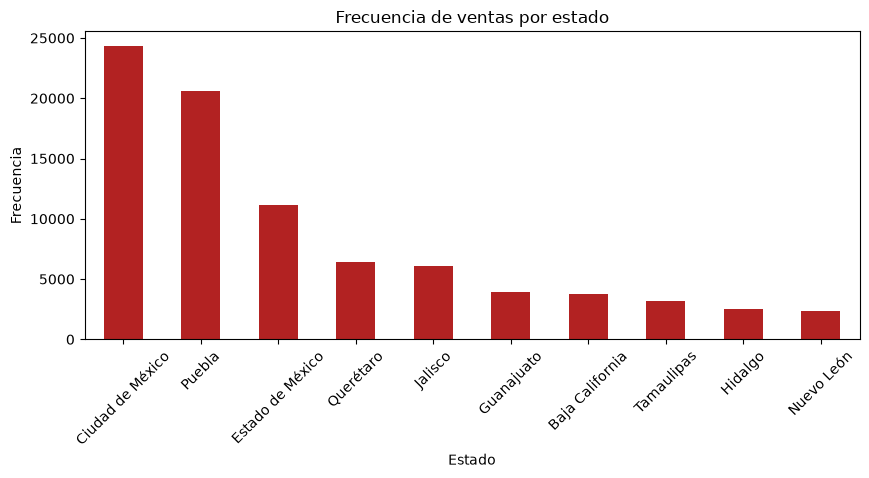

In [30]:
#Gráfica de los 10 estados con mayor frecuencia
frecuencia_estado.head(10).set_index('estado')['frecuencia'].plot(kind='bar', figsize=(10, 4), color='firebrick')
plt.title('Frecuencia de ventas por estado')
plt.xlabel('Estado')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [21]:
#Análisis univariado de estado
frecuencia_estado = ventas_procesadas['estado'].value_counts().reset_index()
frecuencia_estado.columns = ['estado', 'frecuencia']
frecuencia_estado['porcentaje'] = frecuencia_estado['frecuencia'] / len(ventas_procesadas) * 100
frecuencia_estado

,estado,frecuencia,porcentaje
0,Ciudad de México,24337,21.254836
1,Puebla,20638,18.024297
2,Estado de México,11120,9.711706
3,Querétaro,6423,5.609558
4,Jalisco,6107,5.333578
5,Guanajuato,3911,3.415691
6,Baja California,3778,3.299535
7,Tamaulipas,3196,2.791242
8,Hidalgo,2522,2.202601
9,Nuevo León,2372,2.071598


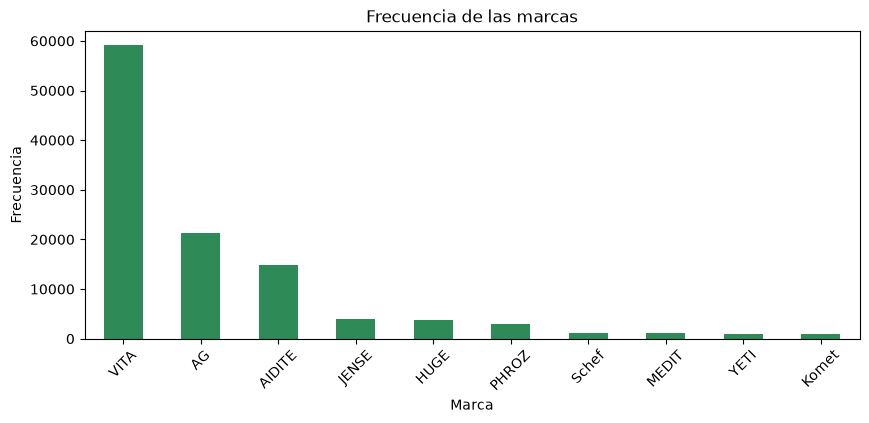

In [25]:
#Gráfica de las marcas con mayor frecuencia
frecuencia_marca.head(10).set_index('marca')['frecuencia'].plot(kind='bar', figsize=(10, 4), color='seagreen')
plt.title('Frecuencia de las marcas')
plt.xlabel('Marca')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [32]:
#Verificamos que el DataFrame procesado no tenga valores nulos
ventas_procesadas.isnull().sum().sum()

np.int64(0)